## Media Politics Group Project Guide

**Group Members**: Erin, Ailie, Cyrus, Nina, Mariam, Martin

**Description**: News media and political leaders both shape and reflect public opinion, but they often frame important political issues differently while also influencing what citizens perceive as salient. This project uses data science to systematically compare government communication and media coverage over time, examining how their relationship changes in response to events such as elections, political scandals, and major policy debates.

**Research Question**: How did the policy agenda emphasized in Prime Minister speeches compare with that of the Japan Times between 2001 and 2021?

**Secondary Research Questions**: Which policy issues received consistently greater attention in Prime Minister speeches versus the Japan Times?
How did sentiment toward shared policy issues differ between Prime Minister speeches and the Japan Times? Can AI-based sentiment analysis effectively capture differences in the tone of government and media discourse, and what methodological challenges arise when applying it to political texts?
Can this analytical framework be generalized to compare political and media discourse in other democratic countries?

**Hypothesis**: 
Hypothesis 1: Prime Minister speeches and The Japan Times will exhibit significant differences in the policy issues they prioritize between 2001 and 2021, reflecting the distinct objectives of government leaders and the news media. Rationale: Government speeches are intended to promote and justify policy agendas, while news media select issues based on newsworthiness, public interest, and editorial priorities.
Hypothesis 2: AI-based text tokenization and sentiment analysis will identify measurable differences in the tone of policy discussions between Prime Minister speeches and The Japan Times*, but its performance will be constrained by the complexity and nuance of political language. Rationale: Political speeches often employ diplomatic, strategic, or deliberately neutral language that may not be fully captured by automated sentiment analysis.


In [1]:
# Import Libraries
import pandas as pd
import sys
import os
import importlib
import matplotlib.pyplot as plt


sys.path.append('..')

## 1. Obtain and Clean Data Sources

Select two data sets and clean accordingly. 


## 1a. Obtaining Data: Webscraping

In this case, before any comparison between Prime Minister speeches and Japan Times coverage can be made, the raw scraped output needs to be reduced to a single, clean, analysis-ready dataset. Webscraped data from the World and Japan Database (WJD), maintained by the Institute for Advanced Studies on Asia (IASA) at the University of Tokyo, varies in formatting across years and speech types (policy speeches, Diet addresses, press conferences), so this step identifies which records are usable and standardizes them into one readable structure.

**Criteria for a "clean, readable" record:**
- Contains a parseable date falling within the study window (2001–2021)
- Contains a non-empty speech/article body of sufficient length to be meaningful for tokenization
- Is attributed to a known Prime Minister (not a placeholder or broken scrape)
- Text encoding renders correctly (no mojibake from Shift-JIS/UTF-8 mismatches)
- Duplicate entries (e.g., the same speech scraped twice) are removed

The following is our scraping function for the [The World and Japan Database](https://worldjpn.net/documents/indices/exdpm/index-ENG.html), defined in [`src/scrape_speeches.py`](../src/scrape_speeches.py), and how it was called:

In [21]:
# Import Libraries for Webscraping
import requests
from bs4 import BeautifulSoup
from src.scrape_speeches import SpeechScraper

In [22]:
# Test Response
resp = requests.get("https://worldjpn.net", timeout=15)
print(resp.status_code)

200


In [24]:
# Run python file
scraper = SpeechScraper(delay=1.0)
records = scraper.scrape_all()
df = pd.DataFrame(records)

Fetching index: https://worldjpn.net/documents/indices/exdpm/index-ENG.html
Found 608 English speech links

[1/608] https://worldjpn.net/documents/texts/JPUS/19510907.S1E.html
[2/608] https://worldjpn.net/documents/texts/docs/19770818.S1E.html
[3/608] https://worldjpn.net/documents/texts/exdpm/19880504.S1E.html
[4/608] https://worldjpn.net/documents/texts/exdpm/19910503.S1E.html
[5/608] https://worldjpn.net/documents/texts/exdpm/19910527.S1E.html
[6/608] https://worldjpn.net/documents/texts/exdpm/19920117.S1E.html
[7/608] https://worldjpn.net/documents/texts/exdpm/19920131.S1E.html
[8/608] https://worldjpn.net/documents/texts/exdpm/19920613.S1E.html
[9/608] https://worldjpn.net/documents/texts/exdpm/19920702.S1E.html
[10/608] https://worldjpn.net/documents/texts/exdpm/19921029.S1E.html
[11/608] https://worldjpn.net/documents/texts/exdpm/19940831.S1E.html
[12/608] https://worldjpn.net/documents/texts/JH/19950718.S1E.html
[13/608] https://worldjpn.net/documents/texts/exdpm/19970623.S1E.h

In [25]:
# Display results
speeches_df = df
speeches_df.head(5)

,title,date,place,source,notes,body,url,error
0,Prime Minister Shigeru Yoshida's Speech at the...,"September 7, 1951",San Francisco,"Gaimusho joyaku-kyoku hokika, Heiwa joyaku no ...",,The peace treaty before the Conference contain...,https://worldjpn.net/documents/texts/JPUS/1951...,NaN
1,SPEECH BY PRIME MINISTER TAKEO FUKUDA (Fukuda ...,"August 18, 1977",Manila,The Ministry of Foreign Affairs of Japan,,"President Marcos, Madam Imelda Romualdez Marco...",https://worldjpn.net/documents/texts/docs/1977...,NaN
2,Statement by Prime Minister Takeshita on the O...,"May 4, 1988",London,Ministry of Foreign Affairs of Japan,,Opening a New Era in Japanese-European Relatio...,https://worldjpn.net/documents/texts/exdpm/198...,NaN
3,Policy Speech by Prime Minister Toshiki Kaifu ...,"May 3, 1991",Singapore,"DIPLOMATIC BLUEBOOK 1991, Japan's Diplomatic A...",,"1. Introduction\n\nDistinguished Guests, ladie...",https://worldjpn.net/documents/texts/exdpm/199...,NaN
4,Address by Prime Minister Toshiki Kaifu at the...,"May 27, 1991","Kyoto, Japan","DIPLOMATIC BLUEBOOK 1991, Japan's Diplomatic A...",,"Ladies and gentlemen,\n\nOn behalf of the Gove...",https://worldjpn.net/documents/texts/exdpm/199...,NaN


In [26]:
# Drop columns not needed and rename remaining columns for uniformity, change depending on source
speeches_df = df.drop(columns={"notes", "url", "error", "place"}).dropna()
speeches_df = speeches_df.rename(columns={"body": "text"})
speeches_df.head(5)

,title,date,source,text
0,Prime Minister Shigeru Yoshida's Speech at the...,"September 7, 1951","Gaimusho joyaku-kyoku hokika, Heiwa joyaku no ...",The peace treaty before the Conference contain...
1,SPEECH BY PRIME MINISTER TAKEO FUKUDA (Fukuda ...,"August 18, 1977",The Ministry of Foreign Affairs of Japan,"President Marcos, Madam Imelda Romualdez Marco..."
2,Statement by Prime Minister Takeshita on the O...,"May 4, 1988",Ministry of Foreign Affairs of Japan,Opening a New Era in Japanese-European Relatio...
3,Policy Speech by Prime Minister Toshiki Kaifu ...,"May 3, 1991","DIPLOMATIC BLUEBOOK 1991, Japan's Diplomatic A...","1. Introduction\n\nDistinguished Guests, ladie..."
4,Address by Prime Minister Toshiki Kaifu at the...,"May 27, 1991","DIPLOMATIC BLUEBOOK 1991, Japan's Diplomatic A...","Ladies and gentlemen,\n\nOn behalf of the Gove..."


In [ ]:
# Convert date column to date-time format, and sort by date
speeches_df['date'] = pd.to_datetime(speeches_df['date'], format='mixed', errors='coerce')
speeches_df = speeches_df.dropna(subset=['date'])
speeches_df = speeches_df.sort_values(by='date')
speeches_df.head(5)

,title,date,source,text
0,Prime Minister Shigeru Yoshida's Speech at the...,1951-09-07,"Gaimusho joyaku-kyoku hokika, Heiwa joyaku no ...",The peace treaty before the Conference contain...
1,SPEECH BY PRIME MINISTER TAKEO FUKUDA (Fukuda ...,1977-08-18,The Ministry of Foreign Affairs of Japan,"President Marcos, Madam Imelda Romualdez Marco..."
2,Statement by Prime Minister Takeshita on the O...,1988-05-04,Ministry of Foreign Affairs of Japan,Opening a New Era in Japanese-European Relatio...
3,Policy Speech by Prime Minister Toshiki Kaifu ...,1991-05-03,"DIPLOMATIC BLUEBOOK 1991, Japan's Diplomatic A...","1. Introduction\n\nDistinguished Guests, ladie..."
4,Address by Prime Minister Toshiki Kaifu at the...,1991-05-27,"DIPLOMATIC BLUEBOOK 1991, Japan's Diplomatic A...","Ladies and gentlemen,\n\nOn behalf of the Gove..."


In [ ]:
# Display Results and Save CSV
print(speeches_df.info())
#speeches_df.to_csv('pm_speeches_en.csv')

<class 'pandas.core.frame.DataFrame'>
Index: 600 entries, 0 to 607
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   title   600 non-null    object        
 1   date    600 non-null    datetime64[ns]
 2   source  600 non-null    object        
 3   text    600 non-null    object        
dtypes: datetime64[ns](1), object(3)
memory usage: 23.4+ KB
None


## 1b. Obtaining Data 2: For raw data in CSV form to cleaned data

Unlike the Prime Minister speech data, the Japan Times articles were sourced from an existing, well-structured Kaggle dataset ([Japanese Newspapers 2005–2021](https://www.kaggle.com/datasets/vyhuholl/japanese-newspapers-20052021)), so the raw CSV was already in a clean, readable format with consistent columns for source, date, title, author, and text. This meant minimal preprocessing was needed compared to the webscraped speech data: the main steps were filtering the dataset down to The Japan Times as the source, restricting records to the study period, and removing any duplicate or incomplete entries before the dataset was ready for tokenization and sentiment analysis alongside the Prime Minister speeches. 

In this step, the data was cleaned up from japan_english_news_kaggle.csv to japan_news_cleaned.csv

In [ ]:
# Define filepath to raw CSV data
filename = 'japan_english_news_kaggle.csv'

filepath = f"../data/raw/{filename}"

In [ ]:
# Read CSV to dataframe
news_pd = pd.read_csv(filepath, sep='\t') # sets delimiter to tab, change if needed
news_pd.head(5)

,source,date,title,author,text
0,Mainichi Shimbun,2021-12-06,"Editorial: Japan govt's 20,000-yen handout mis...",NaN,The Japanese government is trying to boost the...
1,Mainichi Shimbun,2021-12-07,Editorial: Time for Japan PM Kishida to delive...,NaN,"Prime Minister Fumio Kishida, who won a public..."
2,Mainichi Shimbun,2021-12-08,"Editorial: 80 years on from Pearl Harbor, acti...",NaN,It has been 80 years since the start of the Pa...
3,Mainichi Shimbun,2021-12-08,"Yoroku: 80 years later, many lessons still not...",NaN,"""The world has changed completely. The era was..."
4,Mainichi Shimbun,2021-12-08,Promoting respect for human rights behind US '...,NaN,The U.S. administration under President Joe Bi...


In [ ]:
# Filter and sort by date 2001 - 2021

news_pd['date'] = pd.to_datetime(news_pd['date'])

start_date = '2001-01-01'
end_date = '2021-12-31'

news_pd_filtered = news_pd[news_pd['date'].between(start_date, end_date)]
news_pd_filtered = news_pd_filtered.sort_values(by='date')

news_pd_filtered.head(5)

,source,date,title,author,text
86,The Japan Times,2001-01-01,Life? Martian meteorite keeps its cool,Rowan Hooper,"“X-Files,” eat your heart out. Supporters of t..."
76,The Japan Times,2001-01-01,Economy expected to limp toward recovery,Mayumi Negishi,The consensus among economists at private thin...
75,The Japan Times,2001-01-01,State-backed Internet expo kicks off,NaN,The government-sponsored virtual Internet expo...
74,The Japan Times,2001-01-01,Foreign workforce movin' on up,Tetsushi Kajimoto,"For a long time, workers coming to Japan from ..."
98,The Japan Times,2001-01-01,Can peace be globalized in the 21st century?,Yoshikazu Sakamoto,The 20th century is usually referred to as a c...


In [ ]:
# Drop na values in text and title
news_pd_filtered = news_pd_filtered.dropna(subset=['title', 'text'])
news_pd_filtered.head(5)

,source,date,title,author,text
86,The Japan Times,2001-01-01,Life? Martian meteorite keeps its cool,Rowan Hooper,"“X-Files,” eat your heart out. Supporters of t..."
76,The Japan Times,2001-01-01,Economy expected to limp toward recovery,Mayumi Negishi,The consensus among economists at private thin...
75,The Japan Times,2001-01-01,State-backed Internet expo kicks off,NaN,The government-sponsored virtual Internet expo...
74,The Japan Times,2001-01-01,Foreign workforce movin' on up,Tetsushi Kajimoto,"For a long time, workers coming to Japan from ..."
98,The Japan Times,2001-01-01,Can peace be globalized in the 21st century?,Yoshikazu Sakamoto,The 20th century is usually referred to as a c...


In [ ]:
# Clean csv info
print(news_pd_filtered.info())

# Save to csv
# JPnews_pd_filtered.to_csv('cleaned.csv', index=False)

<class 'pandas.core.frame.DataFrame'>
Index: 36766 entries, 86 to 33
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   source  36766 non-null  object        
 1   date    36766 non-null  datetime64[ns]
 2   title   36766 non-null  object        
 3   author  12724 non-null  object        
 4   text    36766 non-null  object        
dtypes: datetime64[ns](1), object(4)
memory usage: 1.7+ MB
None


Used this method on all raw data in csv form that we obtained from downloaded datasets online or webscraping. 

## 2. Choose Keywords
We chose the specific keywords through utilizing LLM Agent Olama. Asking it the common phrase: "What are 10 political, single-word, simple keywords closely associated with Japan's [category] strategy in english? Please include short explanations for why each were chosen.")

Included capital and lowercase as well as different english spelling to account for specific english translations (UK English vs. American English)

1. Install ollama app
2. ollama serve
3. ollama pull llama3.2:latest

In [30]:
import requests

OLLAMA_MODEL = "llama3.2:latest"

def llm_ollama(input_text, model=OLLAMA_MODEL):
    response = requests.post(
        "http://localhost:11434/api/chat",
        json={
            "model": model,
            "messages": [{"role": "user", "content": input_text}],
            "stream": False,
        },
        timeout=120,
    )
    response.raise_for_status()
    return response.json()["message"]["content"]

In [31]:
ollama_response = llm_ollama("What are 10 political, single-word, simple keywords closely associated with Japan's defense strategy? Please include short explanations for why each were chosen.")
print(ollama_response)

Here are 10 single-word keywords closely associated with Japan's defense strategy, along with brief explanations:

1. **Self-Defense**: Japan's post-WWII pacifist constitution limits its military capabilities, focusing on self-defense rather than offense.

2. **Deterrence**: Japan's defense strategy relies on deterrence to prevent potential aggressors from attacking the country.

3. **Nuclear**: As a nuclear-armed state, Japan views nuclear deterrence as an essential component of its national security.

4. **Alliance**: Japan's security is closely tied to its alliance with the United States, which provides military protection and stability in East Asia.

5. **Collective Defense**: The U.S.-Japan Security Treaty (1960) commits both countries to mutual defense in case of an attack on either side.

6. **ASEAN+3**: Japan's relations with ASEAN (Association of Southeast Asian Nations) and its three regional partners (China, Korea, and Taiwan) are crucial for its regional security strategy.


In [19]:
CATEGORY_KEYWORDS = {
    "defense": {
        "self defense", "self defence", "ASEAN", "US-Japan Alliance", 
        "NATO", "Triton", "triton", "Maritime Security","maritime security", "DFNS", "Intelligence-Led Operations",
        "Cybersecurity", "cybersecurity", "Alliance Deterrence" "alliance deterrence",
    },
    "economy": {"Abenomics", "stimulus", "monetization", "monetisation", "deflationary", "Abe doctrine", "sustainable growth", "structural reform", 
                "export-led growth", "demographic shift", "stable growth", "Abenomics", "Stimulus", "Monetization", "Deflationary", 
                "Abe doctrine", "Sustainable growth", "Structural reform", "Export-led growth", "Demographic shift", "Stable growth"
    },
    "nuclear": {
        "Deterrence", "Non-proliferation", "Alliance", "Self-defense", "NPT", "SDGT", 
        "Takeshima", "ASEAN", "US-Japan Security Treaty", "Peaceful use", "deterrence",
        "non-proliferation", "alliance", "self-defense",  "peaceful use"
    },
    "immigration": {
        "Quota", "Skilled", "Guestworker", "Refugee", "Integration", 
        "Citizenship", "Asylum", "Pathway", "Talent", "Inclusion", "quota", "skilled", "guestworker", "refugee", "integration", 
        "citizenship", "asylum", "pathway", "talent", "inclusion"
    },
}

## 3. Tokenize Text Data and Count Words
link to files that tokenize data and count words etc.

## 4. Keyword Statistics in Speeches and News Articles 
In this step, we used the selected keywords to see the number of times that they were mentioned in specific speeches and news articles. We will show the separate analysis between speeches and news, covering the same time period as the news articles (2004–2021).
After that we took the key words a step further and found the top 10 most common political phrases and created a word cloud to visualize the frequency of specific terms. 

## 4.1 Speech Analysis

In [13]:
pd.read_csv("../data/clean/combined_speeches_clean.csv", nrows=3)

,Unnamed: 0,speaker/title,date,text
0,0,Statement of Prime Minister Junichiro Koizumi ...,2001-06-02 00:00:00,Having heard the sudden demise of His Majesty ...
1,1,Statement of Prime Minister Junichiro Koizumi,2001-08-13 00:00:00,"The day after tomorrow, August 15, is the fift..."
2,2,Remarks by Prime Minister Junichiro Koizumi at...,2001-09-23 00:00:00,Many lives were lost as a result of the terror...


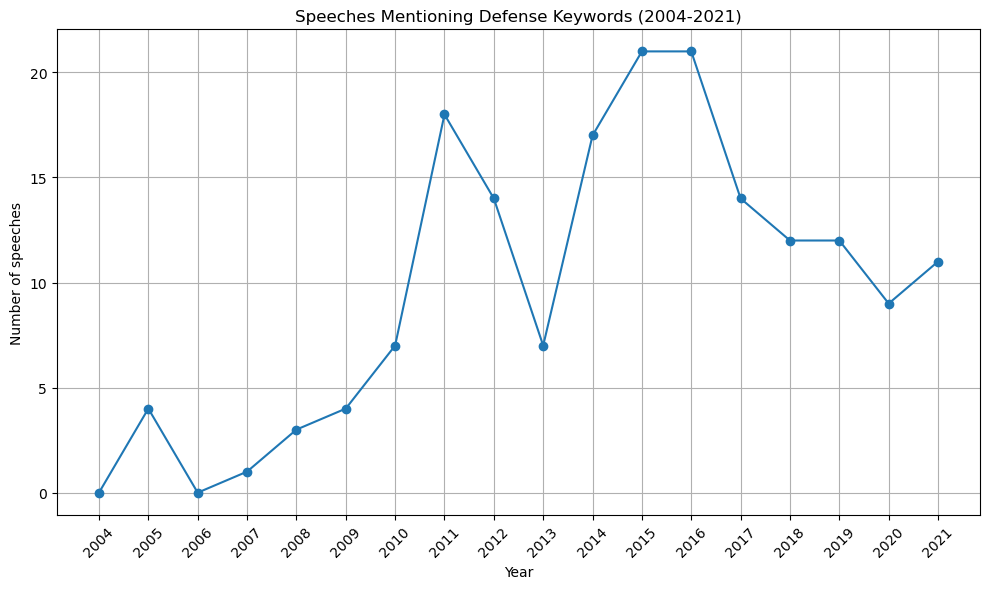

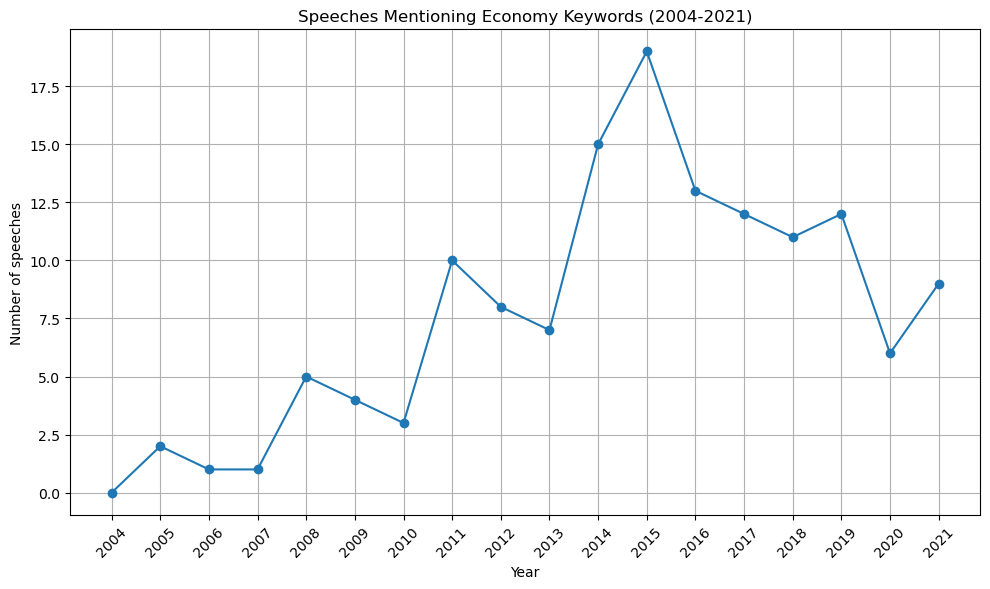

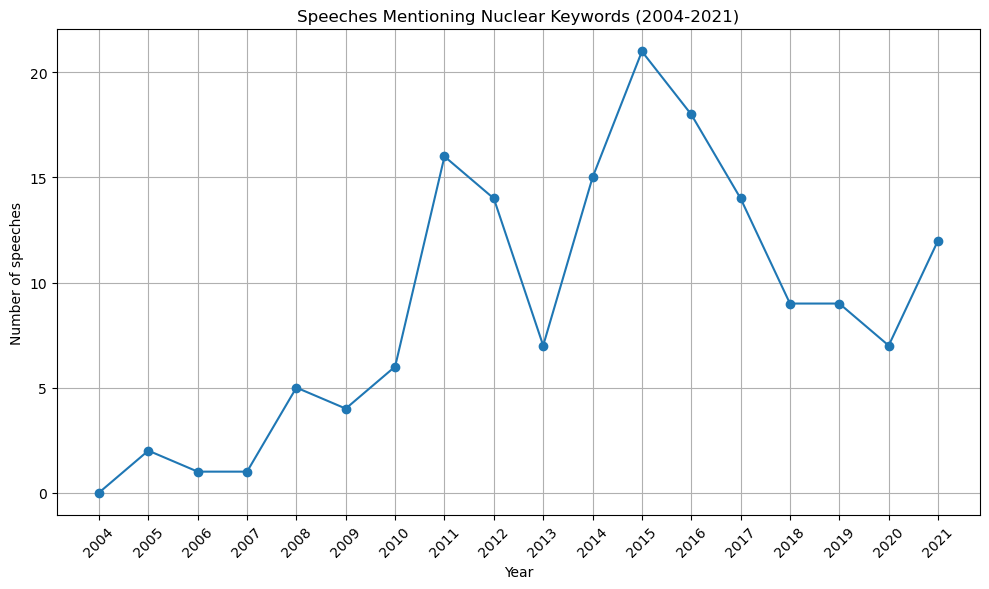

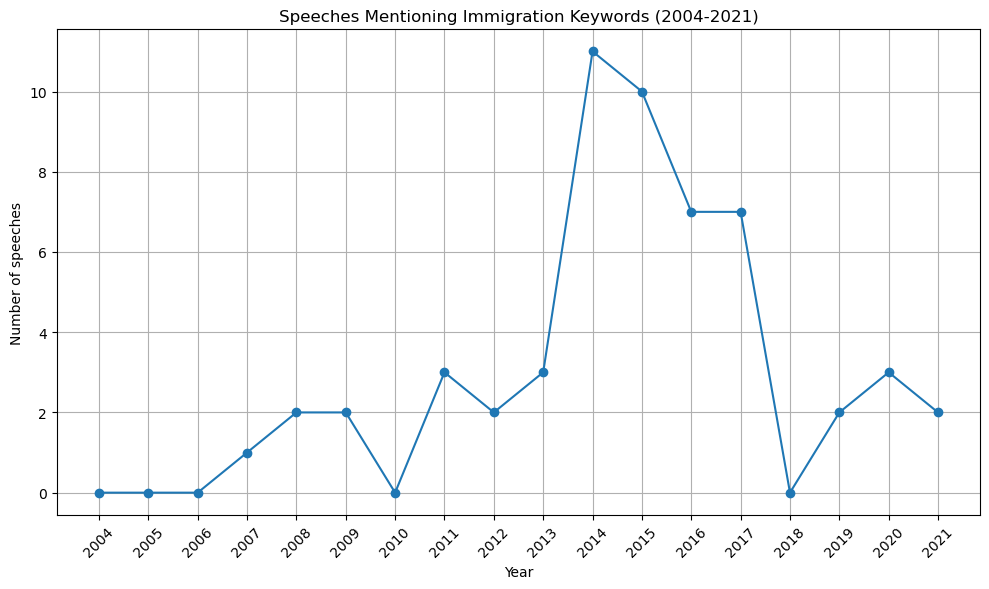

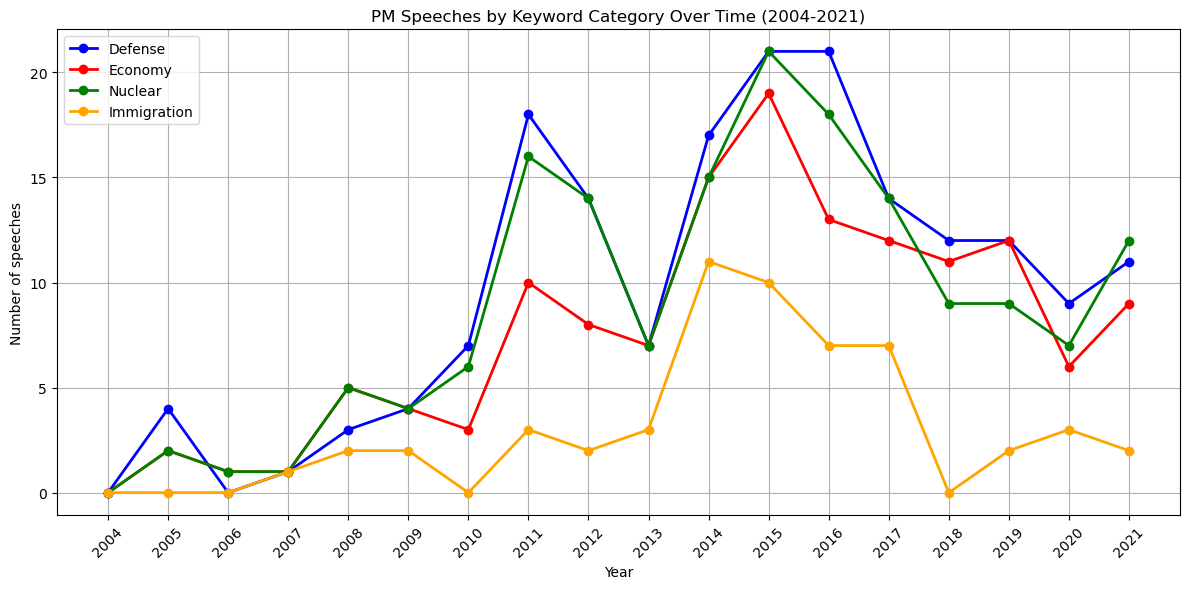

defense: 175 speeches mention this category's keywords
economy: 139 speeches mention this category's keywords
nuclear: 161 speeches mention this category's keywords
immigration: 56 speeches mention this category's keywords


In [22]:
# Speeches mentioning keywords in each category
import pandas as pd
from src.speeches_keywords_analysis import (
    plot_category_trend_charts,
    plot_combined_category_trend_chart,
)

speeches_df = pd.read_csv("../data/clean/combined_speeches_clean.csv")
speeches_df["date"] = pd.to_datetime(speeches_df["date"], errors="coerce")
speeches_df = speeches_df.dropna(subset=["date"]).set_index("date")

plot_category_trend_charts(speeches_df)          
plot_combined_category_trend_chart(speeches_df)  
category_matches = count_category_matches(speeches_df)

In [29]:
from src.speech_analysis_rework import build_top_political_phrases_df
top_political_phrases_df = build_top_political_phrases_df(speeches_df)
top_political_phrases_df.head(5)

,phrase,categories,total_count,doc_freq
0,self defense forces,defense,14,8
1,japan u.s. alliance,nuclear,10,9
2,sustainable growth,economy,7,7
3,u.s.-japan alliance,nuclear,7,4
4,structural reforms,economy,6,4


Visualization: bar chart and word cloud

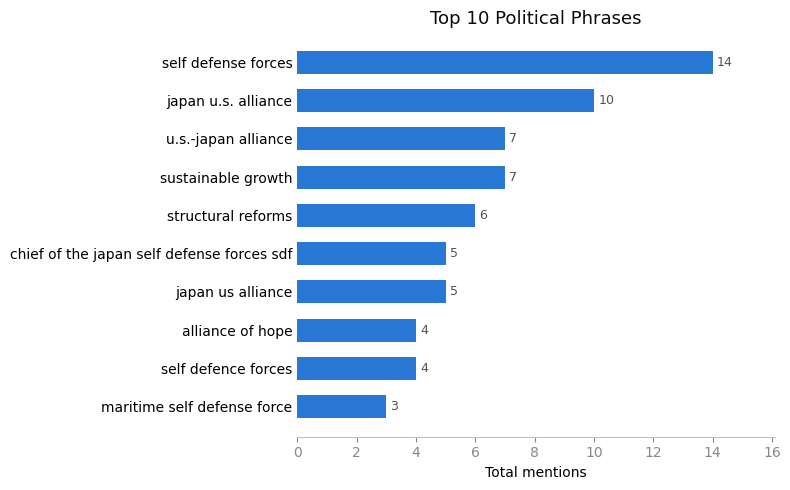

In [25]:
import importlib
import src.speech_analysis_rework
importlib.reload(src.speech_analysis_rework)
from src.speech_analysis_rework import plot_top_political_phrases

plot_top_political_phrases(top_political_phrases_df)


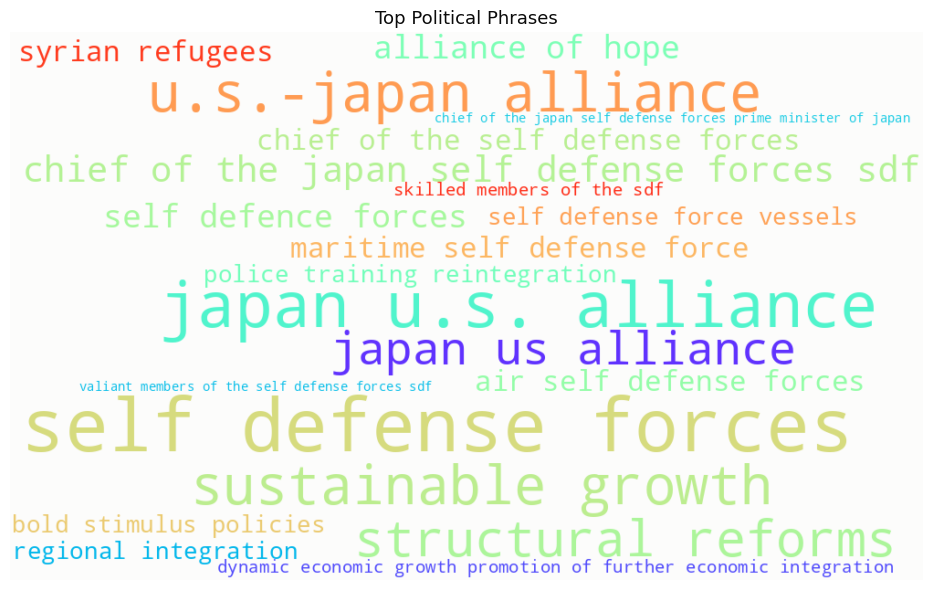

In [28]:
import importlib
import src.speech_analysis_rework
importlib.reload(src.speech_analysis_rework)
from src.speech_analysis_rework import plot_political_phrases_wordcloud

plot_political_phrases_wordcloud(top_political_phrases_df)


## 4.2 News Analysis 
#### 4.2a Basic Information
For news articles, most of them come from The Japan Times. We can see there is an abormally high number of articles before 2004, then it steadily decreased over time until 2021. 

In [2]:
JPnews_pd = pd.read_csv('../data/clean/japan_news_cleaned.csv') 

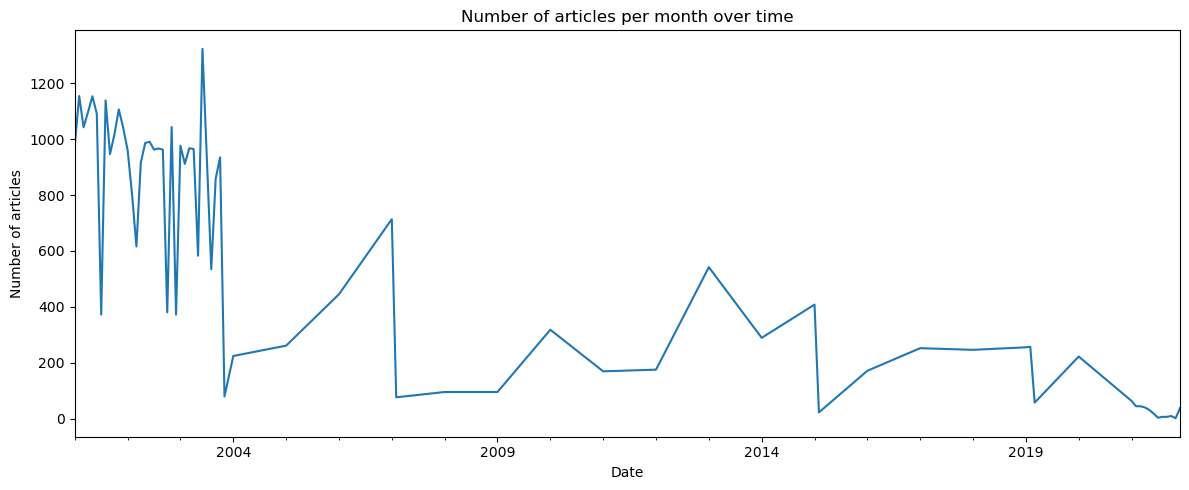

In [3]:
from src.news_analysis_basic import monthly_article_counts, plot_monthly_counts

monthly_count = monthly_article_counts(JPnews_pd)
plot_monthly_counts(monthly_count, save_path='../reports/figures/monthly_article_counts.png')

#### 4.2b Analysis
Then we tried to do the same type of analysis we did for the parliamentary speeches. We tried to look at phrases that appeared the most frequently by deploying Spacy and restricitng the results to nouns, proper nouns and adjectives. 

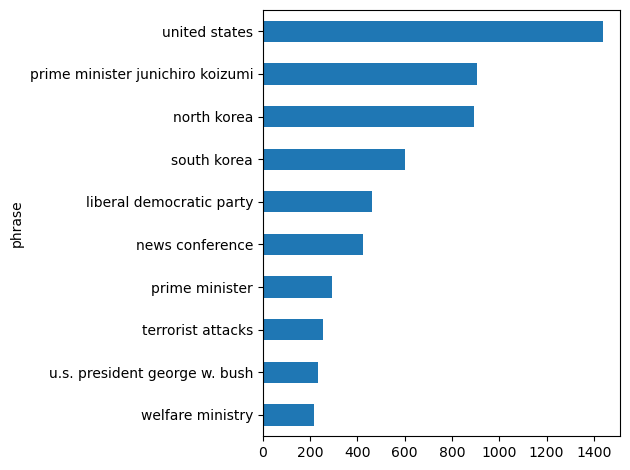

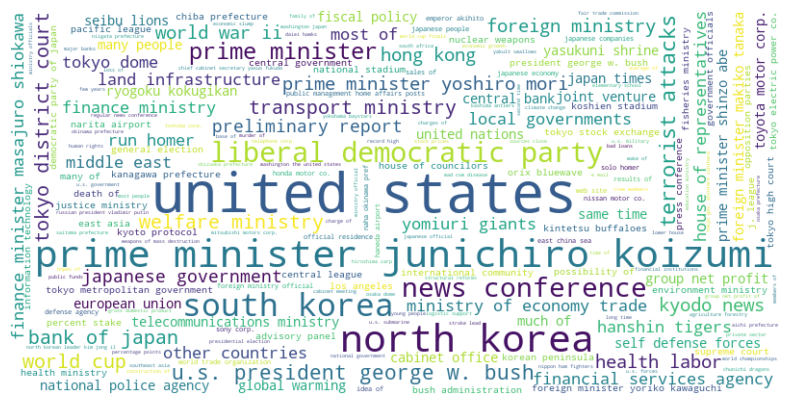

In [4]:
import sys
sys.path.append('..')

from src.news_analysis_basic import extract_noun_phrases, build_top_phrases_df
from src.news_analysis_basic import plot_top_phrases_barh, plot_wordcloud

phrase_counts, phrase_doc_ids = extract_noun_phrases(JPnews_pd)
top_political_phrases_df = build_top_phrases_df(phrase_counts, phrase_doc_ids)

top_political_phrases_df_edited = top_political_phrases_df.drop([0, 1])

plot_top_phrases_barh(top_political_phrases_df_edited)
plot_wordcloud(top_political_phrases_df_edited)

#### 4.2c Keyword analysis
Onto the keyword analysis. We basically did the same thing as what we did to the speeches on our news article dataset. That said, a normalisation was done on the values here. Essentially, the percentage of articles with the certain keywords were used rather than absolute value, to make things easier to compare and factor in the impact of the different number of articles in the dataset. 

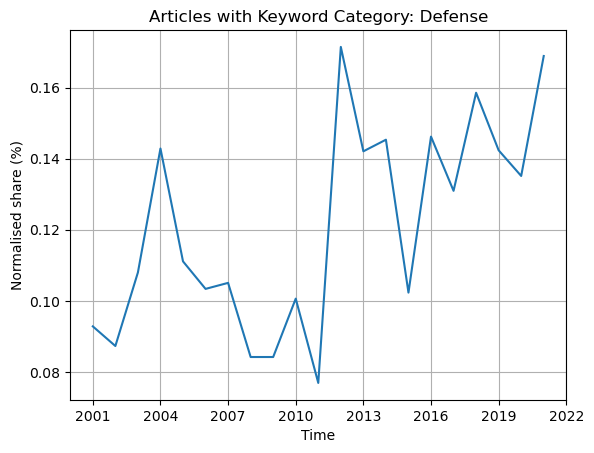

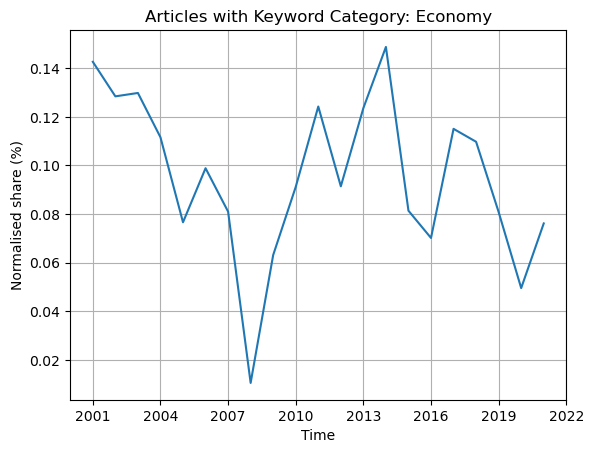

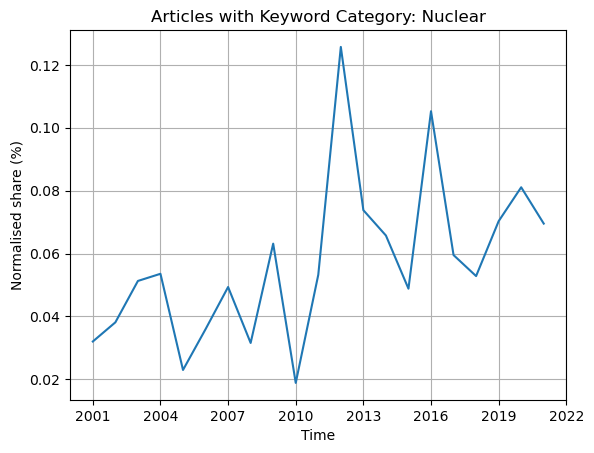

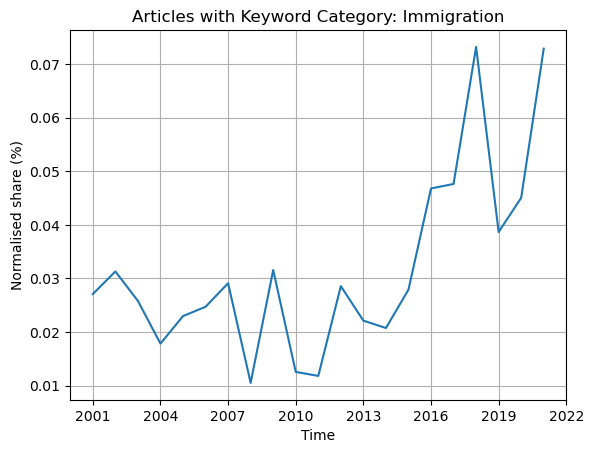

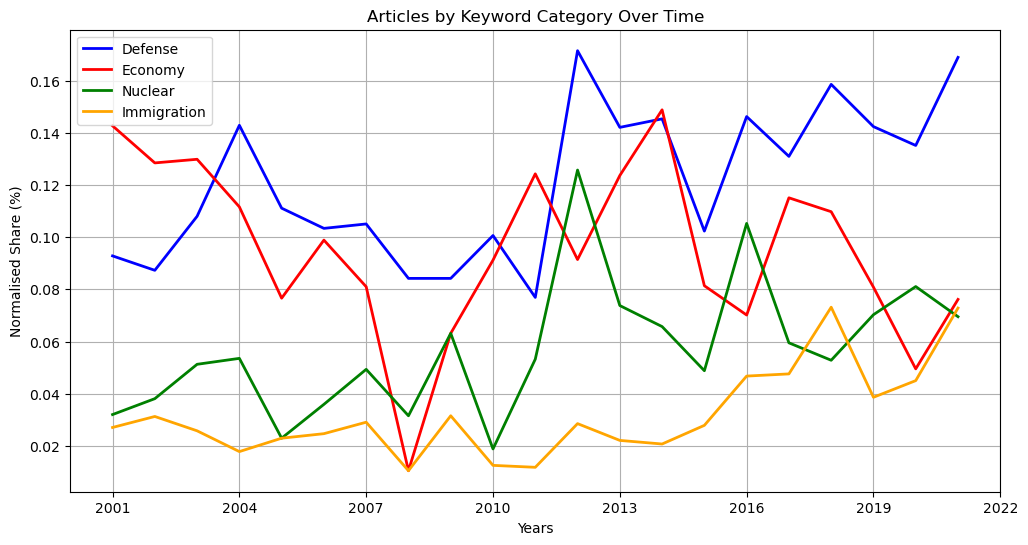

In [5]:
from src.news_analysis_keyword import (
    category_totals_df, build_category_normalised_df,
    plot_category_share, plot_combined_category_shares
)
from src.keywords import CATEGORY_KEYWORDS

JPnews_pd = JPnews_pd.copy()
JPnews_pd["date"] = pd.to_datetime(JPnews_pd["date"], errors="coerce")

JPnews_pd_filtered = JPnews_pd[
    (JPnews_pd["date"] >= "2001-01-01") &
    (JPnews_pd["date"] <= "2021-12-31")
].copy()

category_totals = category_totals_df(CATEGORY_KEYWORDS, JPnews_pd_filtered)
category_totals

category_normalised = build_category_normalised_df(CATEGORY_KEYWORDS, JPnews_pd_filtered)

for category in CATEGORY_KEYWORDS.keys():
    fig = plot_category_share(
        category, category_normalised,
        save_path=f"../reports/figures/{category}_articles_plot.png"
    )
    plt.show()

plot_combined_category_shares(
    CATEGORY_KEYWORDS, category_normalised,
    save_path="../reports/figures/combined_categories_plot.png"
)
plt.show()

## 5. Graph and Analyze

#### 5a. Regression analysis 
We wanted to know whether there is any relationship between the frequency of keywords in the speeches and the news articles. Scatter plots are plotted with each point representing the keyword category's frequency in the two datasets respectively in a given year. Then a regression line is plotted on top of the graph to examine the relationship over time. 

The normalised value of the article analysis is used against a normalised version of the speech keyword analysis. The same method of normalisation was employed as mentioned right above. 

An upward sloping regression line should be visible should there exist any positive relationship between the mentioning of some keywords in speeches and articles. The positive relationship could manifest in terms of parliamentary coverage of a topic influences media attention on social issues, or vice versa. It is understood that the limited number of data points (number of years) make the results not hollistic enough to draw meaningful conclusions, but this is the most optimal analysis option under the practical constraints on time and dataset comprehensiveness. 

In [1]:
import os
print(os.getcwd())
print(os.listdir())

/Users/cyrusng/Documents/GitHub/Media-Politics/project/notebooks
['basic_statistics.ipynb', 'news_analysis.ipynb', 'manifesto_API.ipynb', 'pdf_scraping.ipynb', 'NYT_news_analysis.ipynb', 'attempt_timeline.ipynb', 'speeches_download.ipynb', 'Speeches_Mariam.ipynb', 'speeches_keywords_AILIE.ipynb', 'sentiment_analysis.ipynb', 'defense_newsvspeech_comparison.png', 'manifesto_keywords.ipynb', 'ollama_keywords.ipynb', 'ollama_filtering.ipynb', 'speech_analysis.ipynb', 'media_politics_guide.ipynb', 'spacy-test.ipynb', 'speeches_analysis_cyrus.ipynb']


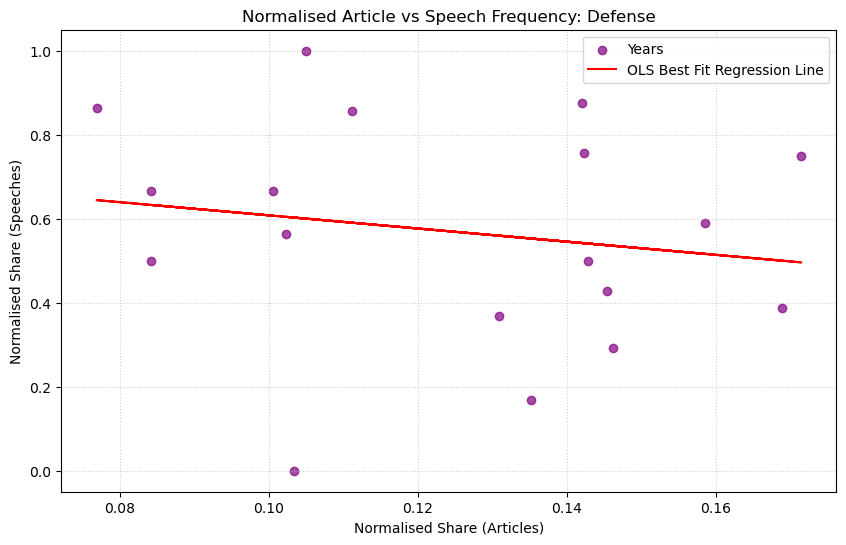

Defense: R²=0.031, p-value=0.488


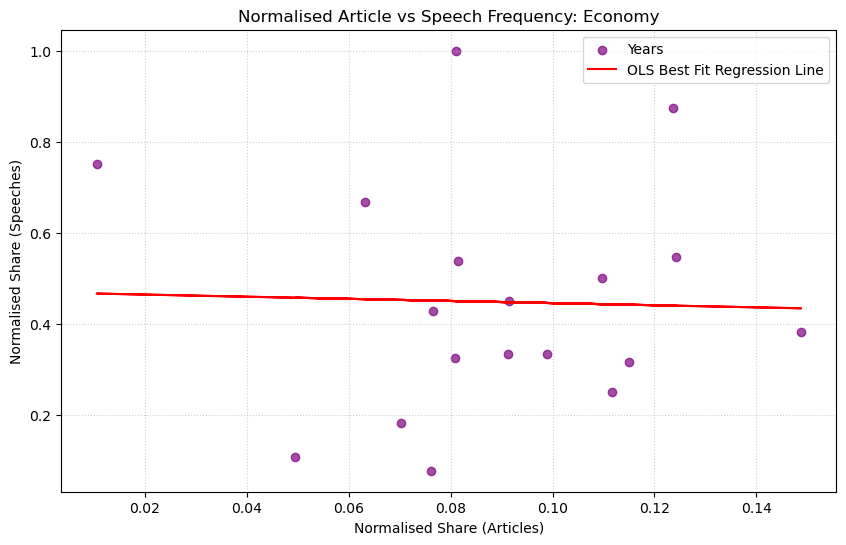

Economy: R²=0.001, p-value=0.908


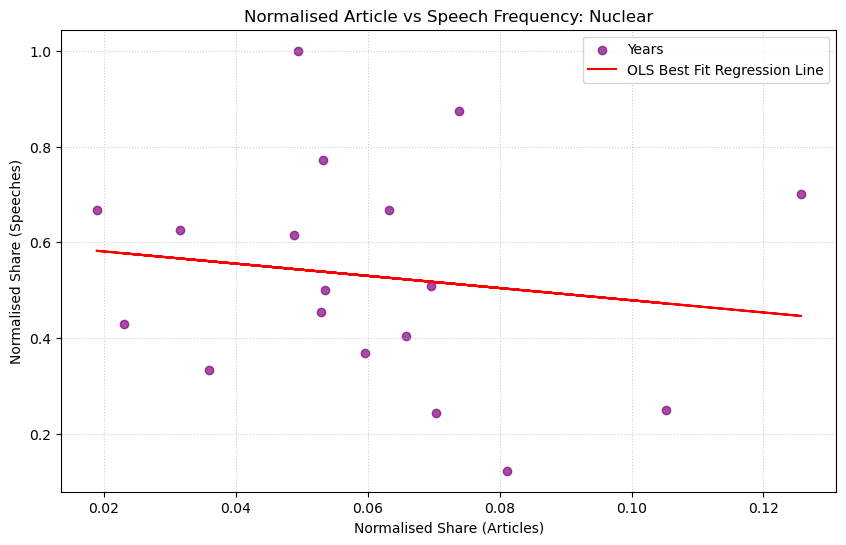

Nuclear: R²=0.022, p-value=0.560


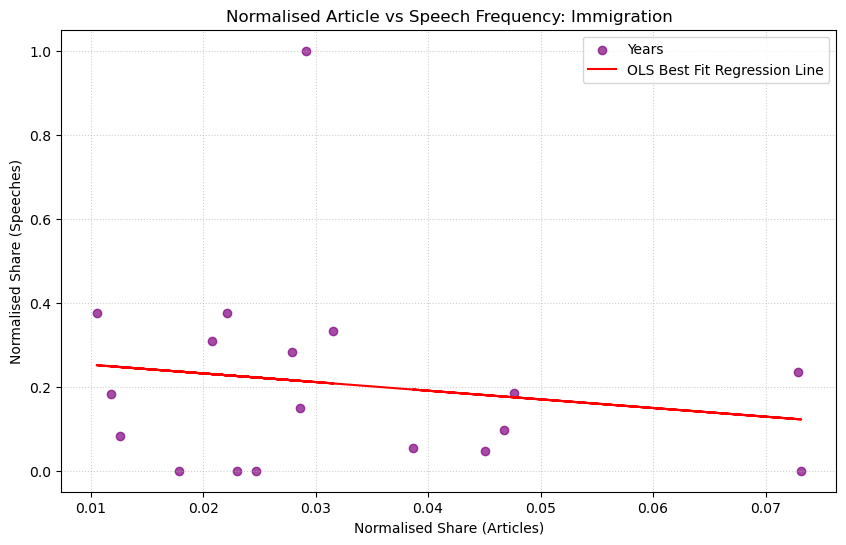

Immigration: R²=0.026, p-value=0.525


In [2]:
import sys
sys.path.append("..")

import importlib
import src.regression_analysis as regression
importlib.reload(regression)

regression.main()

So we can see that all the regression lines are in negative slopes, showing that there is no clear positive corrleation between word frequency in parlimentary speeches and in news articles. The hypothesis that the two factors are mutually reinforcing does not hold according to the analysis done above. 

#### 5b. Graphs comparing frequency of keyword occurence between news and speeches over time (2001 - 2021)
The following is the function [graph_articles.py](../src/graph_articles.py) used to graph this information and how it was called using Japan's data as an example:

In [3]:
# Imports
from src.graph_articles import keyword_yearly_counts, plot_category

In [4]:
# Read cleaned CSV data for Japan's news and speeches into dataframes
JPspeeches_df = pd.read_csv('../data/clean/combined_speeches_clean.csv')
JPnews_df = pd.read_csv('../data/clean/japan_news_cleaned.csv')

news_results = keyword_yearly_counts(JPnews_df)
speech_results = keyword_yearly_counts(JPspeeches_df)

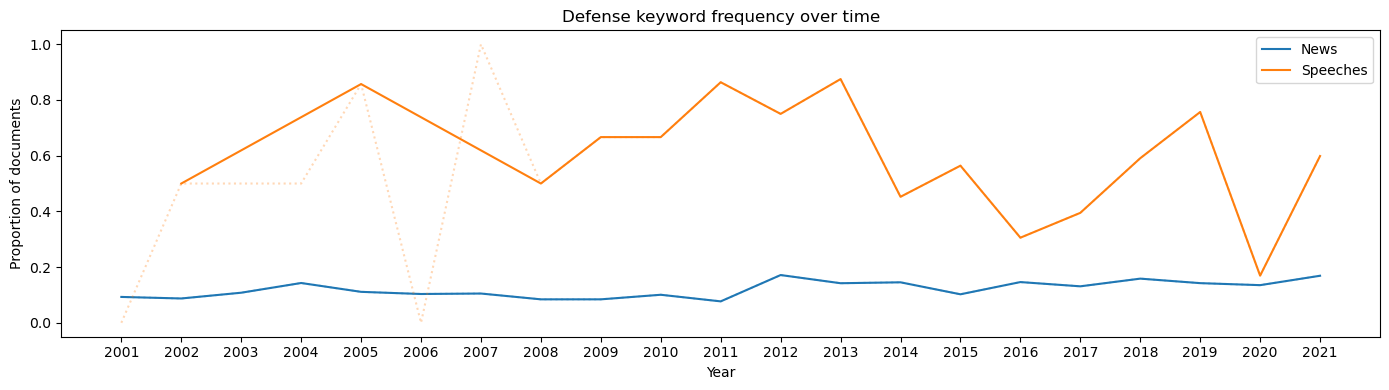

In [5]:
# Output Graphs from graph_articles.py for 'defense' keyword group as an example

plot_category('defense', news_results, speech_results, labels=['News', 'Speeches'])

## 6. Results
With our analysis carried out, we can draw some conclusions. Here are the main figures:

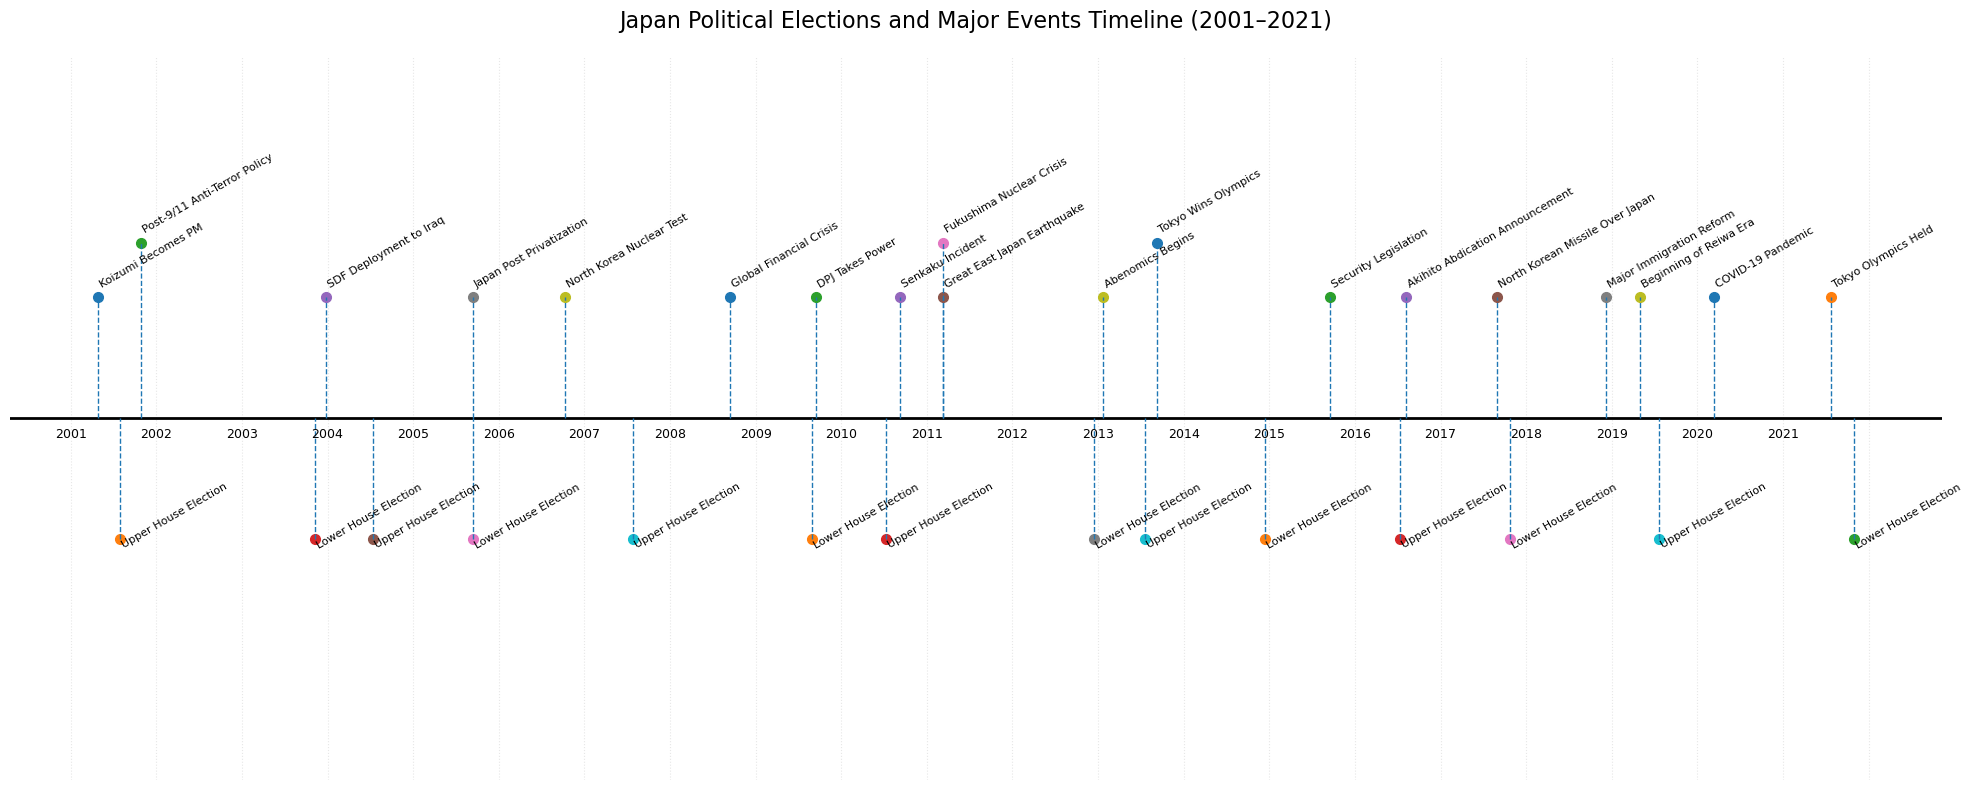

![Keywords in Speeches Over Time](../keyword_categories_speeches_plot.png)

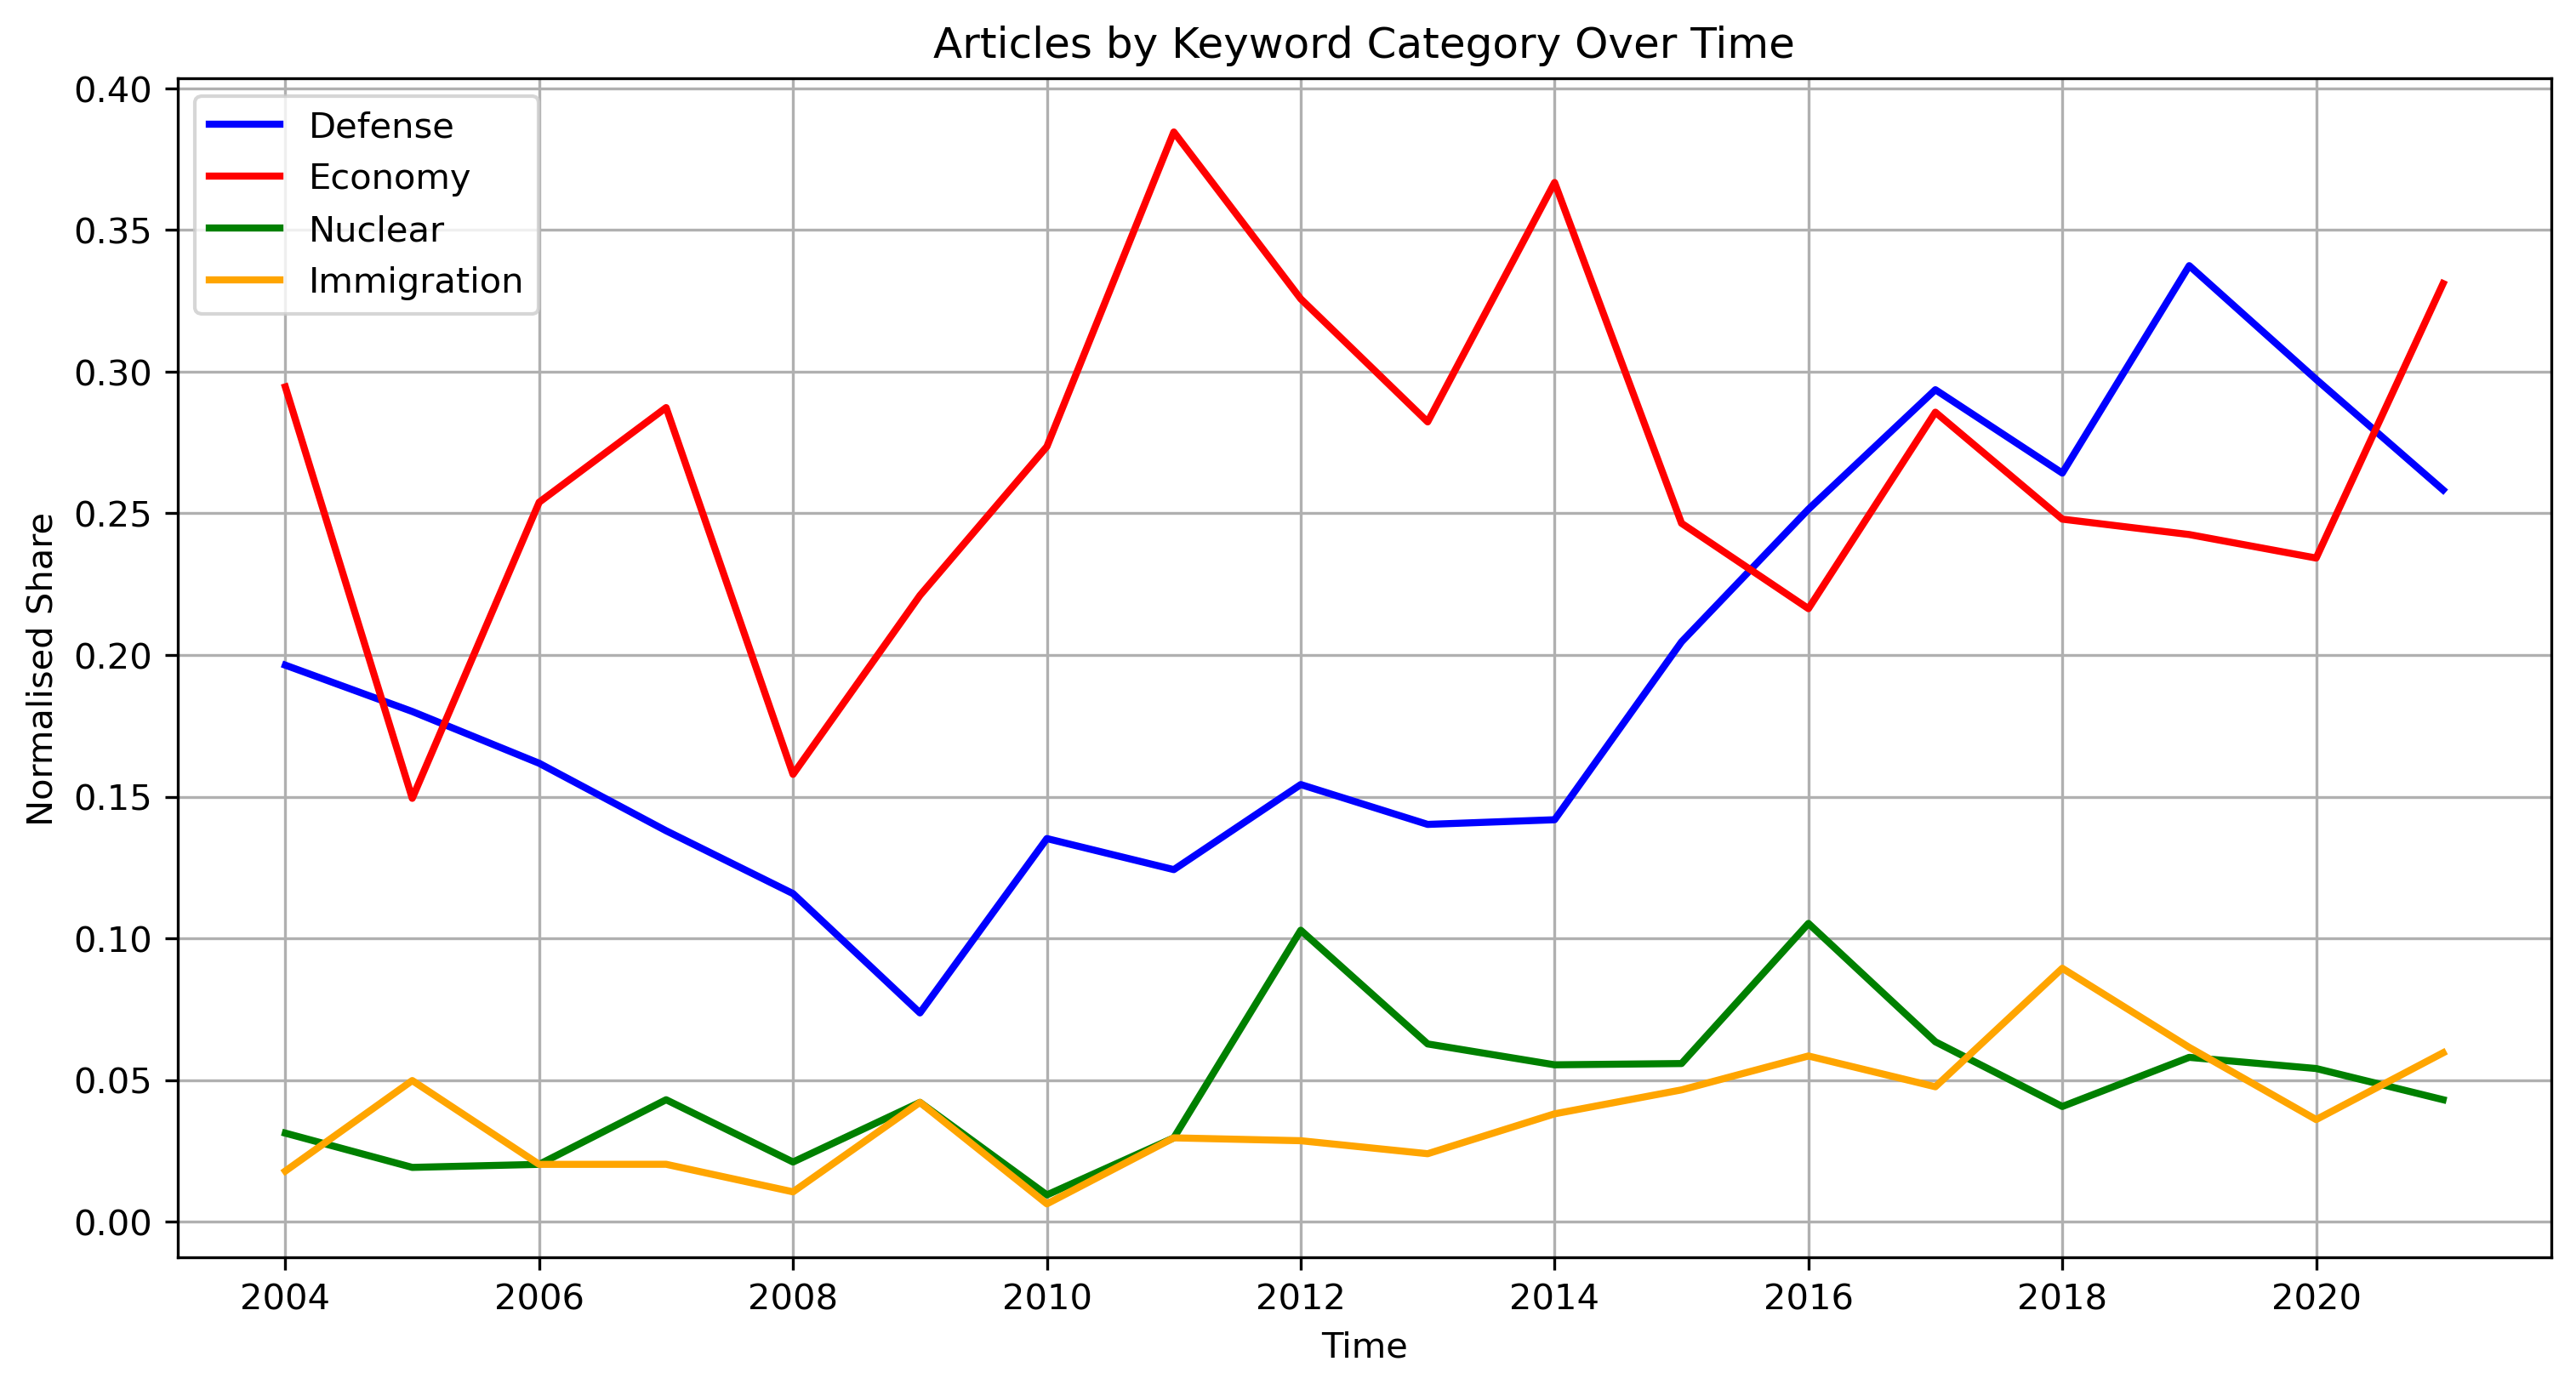

## Conclusion / Key Observations

- **Nuclear discourse spikes sharply following the 2011 Fukushima disaster.** PM speeches mentioning nuclear keywords jump from near-zero in 2010 to 15 mentions in 2011 — the largest single spike in either dataset, reflecting the government's immediate crisis response. News coverage shows a similar but slightly *lagged* spike (peaking around 2012), suggesting media coverage of the nuclear issue persisted and even intensified in the aftermath, beyond the initial political response.

- **Defense keyword mentions rise noticeably from 2016–2019** in both speeches and news, aligning with the passage of Japan's 2015 Security Legislation, ongoing Senkaku Islands tensions, and North Korea's 2017 missile launches over Japan — suggesting defense became a more consistently emphasized policy issue in the latter half of the study period, in both government rhetoric and media framing.

- **Economic keywords dominate news coverage throughout most of the timeline**, with major peaks around 2008–2009 (Global Financial Crisis) and 2011 (economic fallout from the Great East Japan Earthquake), while PM speeches show a comparatively sharper economic peak in 2014, consistent with the rollout and messaging around "Abenomics" (introduced 2013).

- **Immigration remains a minor theme in PM speeches throughout the entire period** (staying at or near zero), even though news coverage shows a distinct rise around 2018, coinciding with Japan's 2018–2019 immigration policy reforms — indicating a gap between media attention and government rhetorical emphasis on this issue.

- **Overall, PM speeches and news coverage tend to track similar large-scale events** (e.g., Fukushima, Abenomics) but diverge in emphasis and timing — speeches often respond immediately to a triggering event (e.g., nuclear in 2011), while news coverage shows more sustained or delayed attention, and covers some issues (like immigration) that receive little direct emphasis from the PM.

- These patterns support **Hypothesis 1**: PM speeches and Japan Times coverage exhibit meaningfully different issue priorities over time, consistent with their distinct institutional roles — one aiming to justify and communicate policy, the other reporting based on newsworthiness and public interest.

## 7. Sentiment Analysis

In order to further investigate this research and provide more insight into what context these topics were raised in, we conducted sentiment analysis using Ollama to compare the general sentiment surrounding these key words. Note that this was a further application of the project and was conducted more as an experiment of Ollama with many potential improvement points.

In [31]:
import sys, os
sys.path.append(os.path.abspath(".."))
from src.sentiment_analysis import run_topic_sentiment, plot_sentiment_comparison

In [32]:
# Read cleaned CSV data for Japan's news and speeches into dataframes
import pandas as pd

JPspeeches_df = pd.read_csv('../data/clean/japan_speeches_cleaned.csv')
JPnews_df = pd.read_csv('../data/clean/japan_news_cleaned.csv')

## Sentiment Analysis Methodology

After loading the two cleaned datasets, we used an LLM (Ollama's `llama3.2` to score how each topic is treated in a sample of news articles and Prime Minister speeches.

The two data sources use slightly different prompts, since they're evaluating different things:

- **News articles** are scored for overall *sentiment* — how positively or negatively the topic is portrayed in the coverage.
- **PM speeches** are scored for *government stance* — whether the Prime Minister presents the topic as something the government supports, opposes, or discusses neutrally. The prompt explicitly excludes emotional tone or writing style, focusing only on the policy position being conveyed.

For each topic (e.g. Immigration, China, Nuclear, Deflation, North Korea), we filtered the dataset by keyword, randomly sampled up to 20 matching documents, and sent each one to the LLM individually. Each response returns:

- **Score**: an integer from -2 to 2
  - -2 = strongly opposed / strongly negative
  - -1 = somewhat opposed / somewhat negative
  - 0 = neutral, descriptive, or no clear position
  - 1 = somewhat supportive / somewhat positive
  - 2 = strongly supportive / strongly positive
- **Frame**: the dominant policy lens used to discuss the topic (e.g. Economic, Security, Diplomatic)
- **Key sentence**: the sentence the model identified as most representative of its scoring
- **Reasoning** : a brief justification for the assigned score and frame

We then averaged the scores across each topic's sample to produce a single comparable value per topic, per source — which is what powers the news-vs-speeches comparison chart below.

In [12]:
news_results = run_topic_sentiment(JPnews_df, source="news")
speech_results = run_topic_sentiment(JPspeeches_df, source="speech")

Analyzing Immigration (news)...
Average Immigration sentiment (news): -1.0
Analyzing China (news)...
Average China sentiment (news): -0.8181818181818182
Analyzing Nuclear (news)...
Average Nuclear sentiment (news): -1.0
Analyzing Constitution (news)...
Average Constitution sentiment (news): -0.6666666666666666
Analyzing Deflation (news)...
Average Deflation sentiment (news): -0.8571428571428571
Analyzing North Korea (news)...
Average North Korea sentiment (news): -1.5714285714285714
Analyzing Immigration (speech)...
Average Immigration sentiment (speech): 1.2
Analyzing China (speech)...
Average China sentiment (speech): 0.05
Analyzing Nuclear (speech)...
Average Nuclear sentiment (speech): 1.05
Analyzing Constitution (speech)...
Average Constitution sentiment (speech): 1.588235294117647
Analyzing Deflation (speech)...
Average Deflation sentiment (speech): 0.9285714285714286
Analyzing North Korea (speech)...
Average North Korea sentiment (speech): -0.1


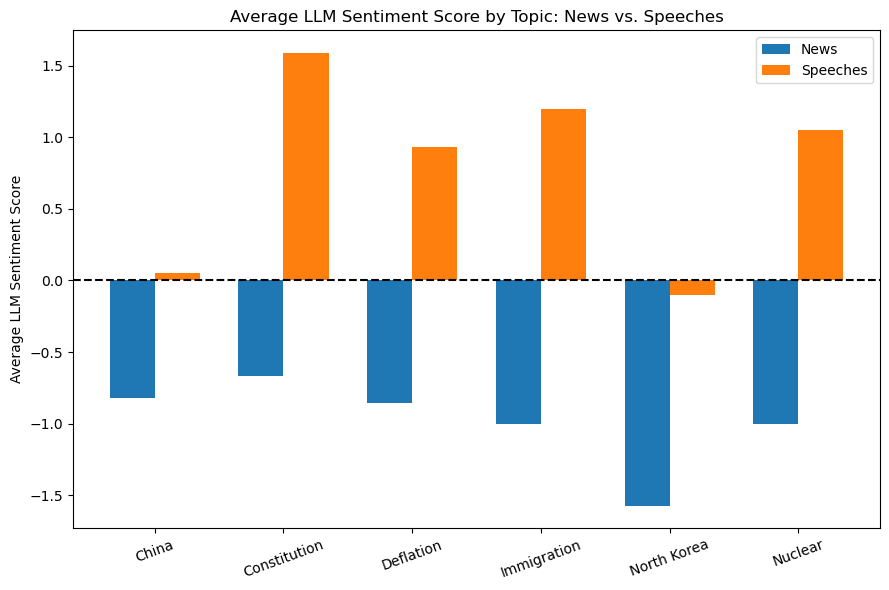

In [13]:
plot_sentiment_comparison(news_results, speech_results, labels=["News", "Speeches"])

In [14]:
import pandas as pd

topics = sorted(set(news_results) & set(speech_results))

summary_table = pd.DataFrame({
    "Topic": topics,
    "News Sentiment": [news_results[t]["score"].mean() for t in topics],
    "Speech Stance": [speech_results[t]["score"].mean() for t in topics],
})
summary_table["Difference (News - Speech)"] = (
    summary_table["News Sentiment"] - summary_table["Speech Stance"]
)
summary_table

,Topic,News Sentiment,Speech Stance,Difference (News - Speech)
0,China,-0.818182,0.050000,-0.868182
1,Constitution,-0.666667,1.588235,-2.254902
2,Deflation,-0.857143,0.928571,-1.785714
3,Immigration,-1.000000,1.200000,-2.200000
4,North Korea,-1.571429,-0.100000,-1.471429
5,Nuclear,-1.000000,1.050000,-2.050000


In [20]:
from src.sentiment_analysis import ArticleSentimentAnalyzer

analyzer = ArticleSentimentAnalyzer(backend="ollama")

def summarize_topic_results(results):
    summaries = {}
    for topic, df in results.items():
        text = "\n\n".join(df["raw"].dropna().tolist())

        prompt = f"""
Summarize the findings for {topic}.

Include:
- overall sentiment
- dominant frames
- recurring themes

Keep to 4-5 sentences.

{text[:12000]}
"""
        summaries[topic] = analyzer.query_llm(prompt)
    return summaries

news_summaries = summarize_topic_results(news_results)
speech_summaries = summarize_topic_results(speech_results)

## 8. Applying These Findings to Another Dataset

To take our analysis further, we applied the same framework to a second country as a generalizability check for **Secondary Research Question 4** (whether this analytical approach can be extended to other democratic countries). We used the **New York Times Index** and **State of the Union Speeches**, both provided by the [Comparative Agendas Project](https://www.comparativeagendas.net/), to see whether a similar comparison could be made between government communication and news media coverage in the United States.

Unlike our Japan datasets, no webscraping was necessary here as the Comparative Agendas Project already provides both datasets in clean, structured CSV form with pre-coded policy topics, so this step focused on adapting our existing keyword-matching and visualization pipeline to this new data rather than on data collection or cleaning.

In the case of the US, we do see more clear correlations in the frequency of keywords in US State of the Union speeches and New York Times articles. For example, the keyword category of defence:

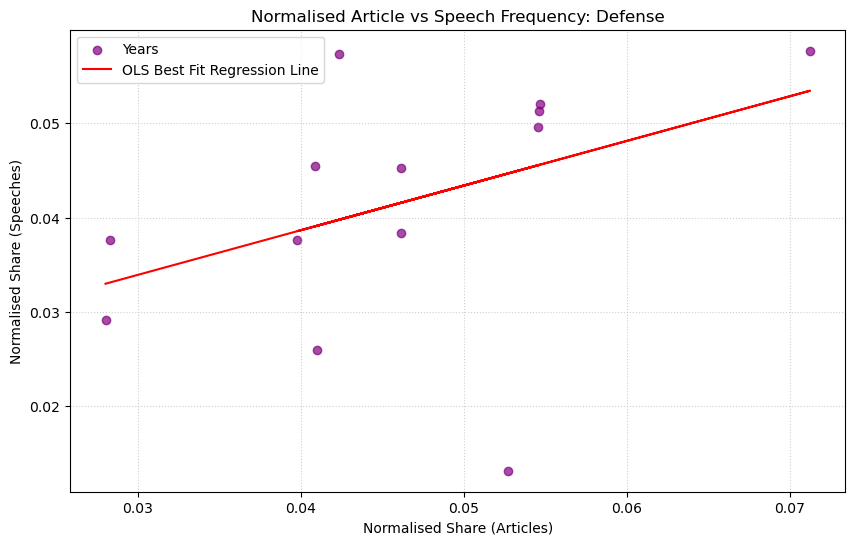

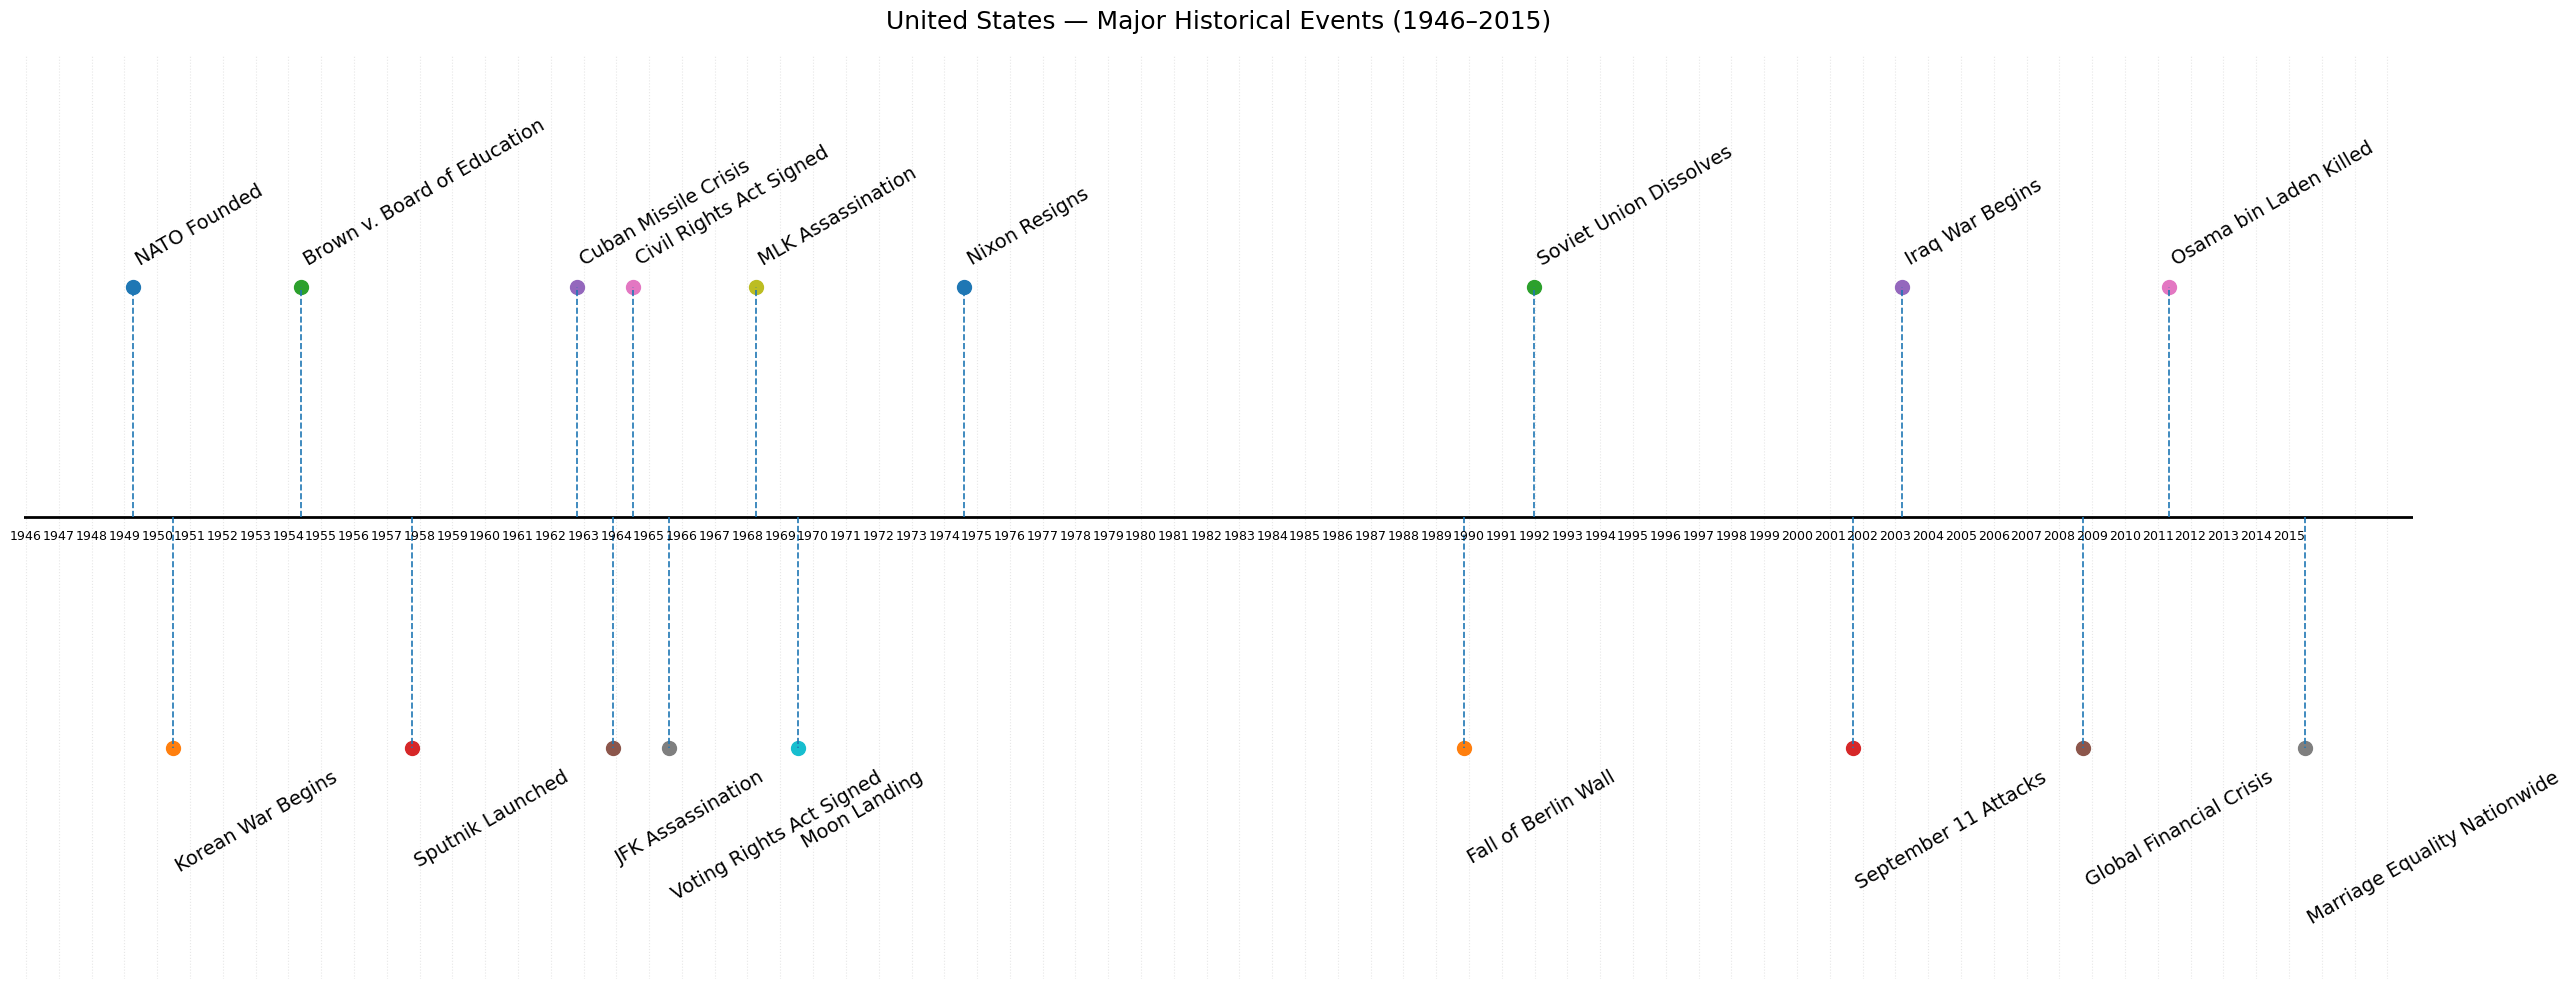

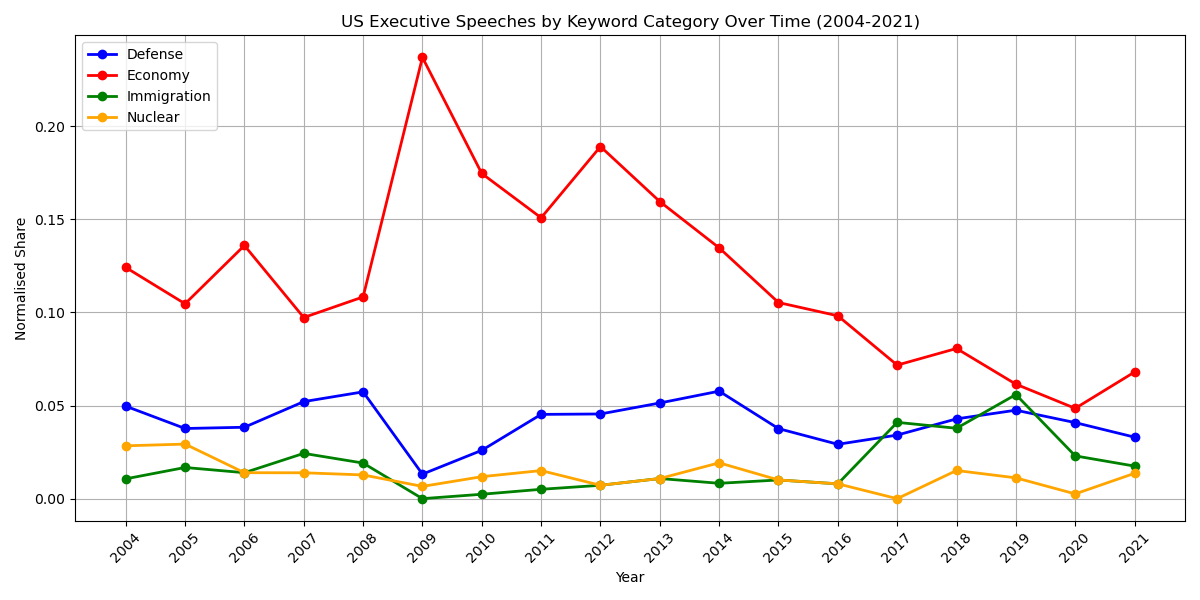

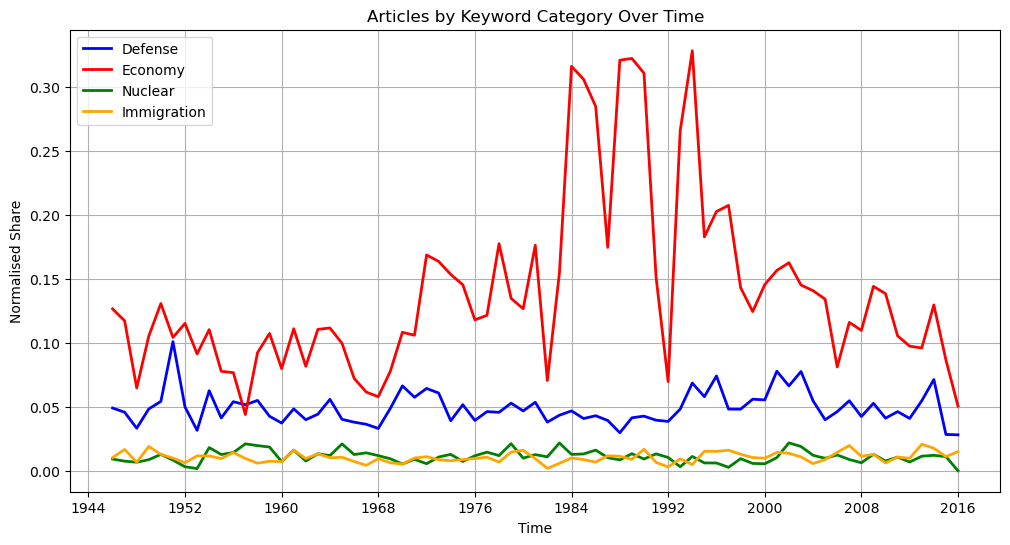

## 9. General Conclusions

- **We applied core data visualization and text-analysis skills to compare political topics across two different mediums** — government speeches and news media — allowing us to systematically identify where PM speeches and Japan Times coverage aligned or diverged in their policy emphasis over a 20-year period.

- **Choosing accessible, well-prepared data proved just as important as the analysis itself**, particularly when working with non-English language sources. We initially attempted to use Japanese political party manifestos as a data source, but scraping these proved extremely difficult: the vertical text direction and heavy use of embedded images and scanned photographs confused our scraping tools (e.g. Spacy struggled to parse text order and structure correctly). This pushed us toward the World and Japan Database and Kaggle-hosted news datasets instead, which were far more machine-readable.

- **AI-based sentiment analysis showed both promise and clear limitations when applied to political language.** It was necessary to conduct sentiment analysis as our next step to see the wider context in which these topics were discussed rather than the frequency. While it captured broad tonal differences between government and media discourse, it struggled with the deliberately diplomatic, hedged, or strategically neutral phrasing common in political speeches, supporting our second hypothesis that automated sentiment tools are constrained by the nuance of political rhetoric. Further, this demonstrates gaps in AI's ability to read sentiment. Additionally, we could work on improving our prompts to ensure we get the correct level of analysis we need. 

- **Extending our framework to a second country (the United States) demonstrated that the overall approach generalizes reasonably well**, though it also required adapting to a different topic-coding scheme (Comparative Agendas Project categories) rather than our original custom keyword list. We therefore hope we are able to use this kind of framework from our guide for other instances in which we have to compare two datasets. 

- **Major real-world events (e.g., the 2011 Fukushima disaster, the 2008 Global Financial Crisis, the 2015 Security Legislation) consistently corresponded to measurable spikes in topic salience**, reinforcing that both government communication and media coverage are responsive to, and shaped by, real political and social shocks rather than following a stable, predictable agenda over time.

- **Working as a team of six on a shared codebase and dataset pipeline reinforced the importance of clear file structure and naming conventions** (e.g., consistent `data/raw/`, `data/clean/`, and `figures/` folders), especially for reproducibility — since relative paths, column naming, and cleaning steps needed to stay consistent across everyone's individual contributions to the notebook.

- **Further Applications**
This guidebook can be used for future projects where we may have to compare two datasets where sentiment or topic salience have to be compared between the two. With further improvements on sentiment analysis prompting, data visualization, and data scraping, we hope that this guide can be used for individual projects in the future. 